In [12]:
from diptest import diptest
from matplotlib import pyplot as plt
from scipy import stats
import numpy as np

rd_seed = 42

## Hartigan's Dip Test for Multi-modality

null hypothesis: distribution is uni-modal

alternative hypothesis: distribution is multi-modal


### Uni-modal - small dataset (1000)

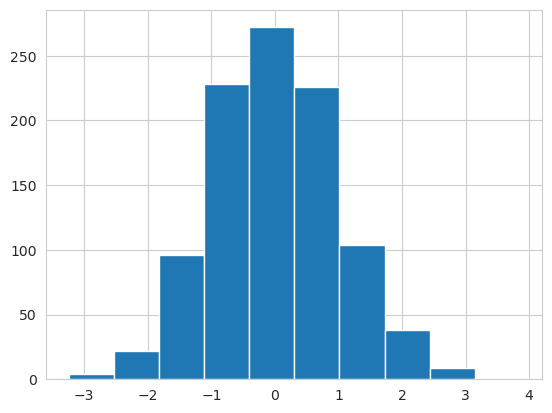

In [5]:
n = 1000
std_norm_sample = stats.norm.rvs(size=n, random_state=rd_seed)

fig, ax = plt.subplots()
ax.hist(std_norm_sample)
plt.show()

In [7]:
statistic, p_value = diptest(std_norm_sample)
print(f'statistic: {statistic}\np-value: {p_value}')

statistic: 0.01088746741536804
p-value: 0.6407097573767897


We cannot reject that data comes from uni-modal distribution

### Uni-modal - medium dataset (70000)


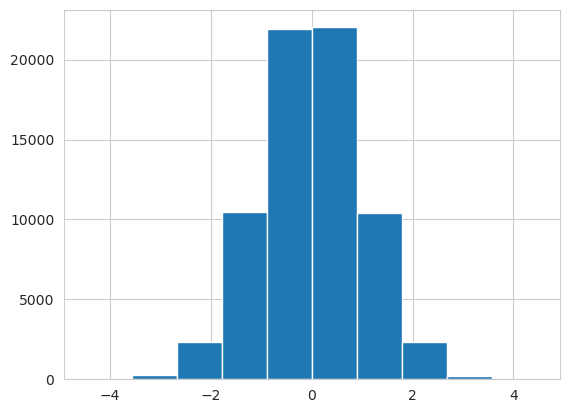

In [8]:
n = 70000
std_norm_sample = stats.norm.rvs(size=n, random_state=rd_seed)

fig, ax = plt.subplots()
ax.hist(std_norm_sample)
plt.show()

In [9]:
statistic, p_value = diptest(std_norm_sample)
print(f'statistic: {statistic}\np-value: {p_value}')

statistic: 0.0005749226939829913
p-value: 1.0


Again, we cannot reject that it is uni-modal distribution.

### Uni-modal - large dataset (500000)


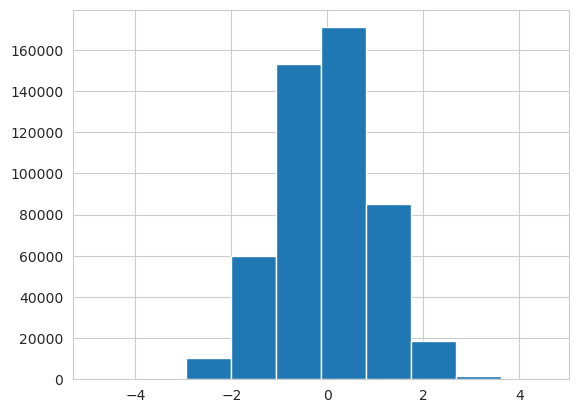

In [10]:
n = 500000
std_norm_sample = stats.norm.rvs(size=n, random_state=rd_seed)

fig, ax = plt.subplots()
ax.hist(std_norm_sample)
plt.show()

In [17]:
statistic, p_value = diptest(std_norm_sample)
print(f'statistic: {statistic}\np-value: {p_value}')

statistic: 0.00018254087668264946
p-value: 1.0


Even with dataset size larger than the limit, results are as expected - cannot reject null hypothesis.

### Bi-modal - large dataset

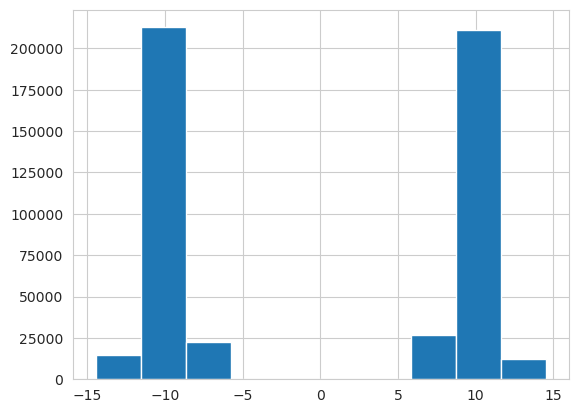

In [14]:
n = 500000
std_norm_sample_m1 = stats.norm.rvs(loc=-10, size=n//2, random_state=rd_seed)
std_norm_sample_m2 = stats.norm.rvs(loc=10, size=n//2, random_state=rd_seed)

compound_sample = np.append(std_norm_sample_m1, std_norm_sample_m2)

fig, ax = plt.subplots()
ax.hist(compound_sample)
plt.show()

In [16]:
statistic, p_value = diptest(compound_sample)
print(f'statistic: {statistic}\np-value: {p_value}')

statistic: 0.18865539249002142
p-value: 0.0


We reject null hypothesis data are uni-modal.

Higher statistic suggests more multi-modality, while lower suggests uni-modality.

### Unbalanced bi-modal - large dataset

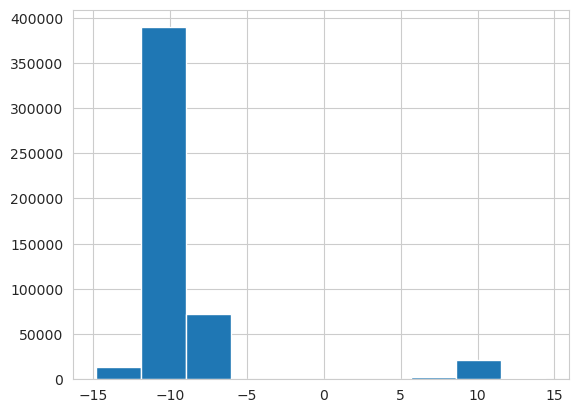

n_m1: 475000
n_m2: 25000


In [25]:
n = 500000
n_m1 = int(n * 0.95)
n_m2 = n - n_m1
std_norm_sample_m1 = stats.norm.rvs(loc=-10, size=n_m1, random_state=rd_seed)
std_norm_sample_m2 = stats.norm.rvs(loc=10, size=n_m2, random_state=rd_seed)

compound_sample = np.append(std_norm_sample_m1, std_norm_sample_m2)

fig, ax = plt.subplots()
ax.hist(compound_sample)
plt.show()

print(f'n_m1: {n_m1}\nn_m2: {n_m2}')

In [26]:
statistic, p_value = diptest(compound_sample)
print(f'statistic: {statistic}\np-value: {p_value}')

statistic: 0.01863231375656073
p-value: 0.0


We see that this test is quite sensitive to outlier modes, which are very small in comparison to the main mode.

Let's try even more unbalanced dataset:

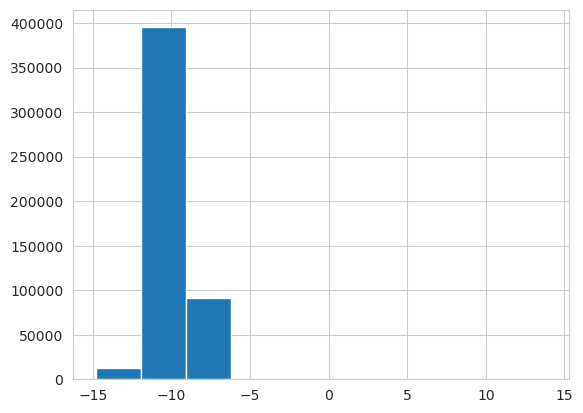

n_m1: 499000
n_m2: 1000


In [31]:
n = 500000
n_m1 = int(n * 0.998)
n_m2 = n - n_m1
std_norm_sample_m1 = stats.norm.rvs(loc=-10, size=n_m1, random_state=rd_seed)
std_norm_sample_m2 = stats.norm.rvs(loc=10, size=n_m2, random_state=rd_seed)

compound_sample = np.append(std_norm_sample_m1, std_norm_sample_m2)

fig, ax = plt.subplots()
ax.hist(compound_sample)
plt.show()

print(f'n_m1: {n_m1}\nn_m2: {n_m2}')

In [32]:
statistic, p_value = diptest(compound_sample)
print(f'statistic: {statistic}\np-value: {p_value}')

statistic: 0.0007466288491966558
p-value: 0.07023795458513382


As we see, the second mode is 0.2% of the data, and the test cannot reject uni-modality.

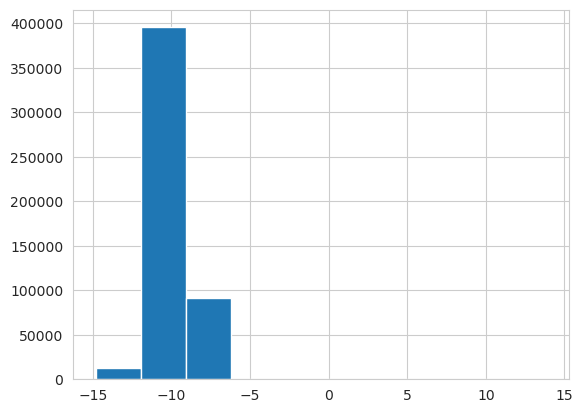

n_m1: 499500
n_m2: 500


In [27]:
n = 500000
n_m1 = int(n * 0.999)
n_m2 = n - n_m1
std_norm_sample_m1 = stats.norm.rvs(loc=-10, size=n_m1, random_state=rd_seed)
std_norm_sample_m2 = stats.norm.rvs(loc=10, size=n_m2, random_state=rd_seed)

compound_sample = np.append(std_norm_sample_m1, std_norm_sample_m2)

fig, ax = plt.subplots()
ax.hist(compound_sample)
plt.show()

print(f'n_m1: {n_m1}\nn_m2: {n_m2}')

In [28]:
statistic, p_value = diptest(compound_sample)
print(f'statistic: {statistic}\np-value: {p_value}')

statistic: 0.00037383833673612513
p-value: 0.9680774057606902


### Insights

- higher statistic suggests more multi-modality
- lower statistic suggests more uni-modality
- quite sensitive to outliers (it is enough to have clustered outliers that make 0.5% of the data and the test is very sure that we have multi-modal distribution)